# MistralAI 7B Instruct Financial QA with Context Grounding

# 1. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/Fine-Tuning/Prism

/content/drive/MyDrive/Fine-Tuning/Prism


In [ ]:
!pip install -q torch==2.9.0 cuda-bindings==12.9.5 "opentelemetry-api<=1.37.0" "opentelemetry-sdk<=1.37.0" unsloth trl peft accelerate bitsandbytes  deepeval datasets rouge-score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.7/405.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.5 MB/s eta 0:

In [ ]:
import torch
import random
import numpy as np

SEED = 47
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-80GB
Memory: 85.2 GB


# Load and Explore Dataset

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("sujet-ai/Sujet-Finance-Instruct-177k", split="train")

print(f"Full Dataset: {len(dataset)} examples")
print(f"Columns: {dataset.column_names}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sujet-ai/Sujet-Finance-Instruct-177k.csv:   0%|          | 0.00/337M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/177597 [00:00<?, ? examples/s]

Full Dataset: 177597 examples
Columns: ['Unnamed: 0', 'inputs', 'answer', 'system_prompt', 'user_prompt', 'task_type', 'dataset', 'index_level', 'conversation_id']


In [ ]:
from collections import Counter

In [ ]:
print("Task Types:")

task_counts = Counter(dataset["task_type"])
for task, count in task_counts.most_common():
  print(f"\t{task}: {count:,}")

Task Types:
	sentiment_analysis: 44,209
	qa_with_context: 40,475
	qa: 38,801
	yes_no_question: 20,547
	topic_classification: 16,990
	qa_conversation: 15,613
	ner_sentiment_analysis: 962


In [ ]:
# filtering for QA with context only examples
qa_dataset = dataset.filter(lambda x:x["task_type"] == "qa_with_context")
print(f"QA with Context: {len(qa_dataset)} examples")

Filter:   0%|          | 0/177597 [00:00<?, ? examples/s]

QA with Context: 40475 examples


In [ ]:
print("===== Example 1 =====")
print(f"System: {qa_dataset[0]['system_prompt'][:200]}")
print(f"User: {qa_dataset[0]['user_prompt'][:300]}")
print(f"Answer: {qa_dataset[0]['answer'][:200]}")

===== Example 1 =====
System: As a finance expert, your role is to provide insightful answers to questions related to finance. Given a specific request and relevant context, carefully analyze the information provided and formulate
User: Request:
Identify the odd one out.

Context:
Twitter, Instagram, Telegram
Answer: Telegram


In [ ]:
# Context and answer lengths
context_lengths = [len(ex['user_prompt'].split()) for ex in qa_dataset]
answer_lengths = [len(ex['answer'].split()) for ex in qa_dataset]

print("Context length (words):")
print(f"\tMin: {min(context_lengths):,} | Max: {max(context_lengths):,} | Mean: {np.mean(context_lengths):,}")

print("Answer length (words)")
print(f"\tMin: {min(context_lengths):,} | Max: {max(context_lengths):,} | Mean: {np.mean(context_lengths):,}")

# Which source datasets contribute to this subset
source_counts = Counter(qa_dataset['dataset'])
print("Source datasets:")
for src, count in source_counts.most_common():
  print(f"\t{src}: {count}")

Context length (words):
	Min: 7 | Max: 1,552 | Mean: 68.85823347745522
Answer length (words)
	Min: 7 | Max: 1,552 | Mean: 68.85823347745522
Source datasets:
	gbharti/finance-alpaca: 19728
	ceadar-ie/FinTalk-19k: 19105
	AdaptLLM/finance-tasks_ConvFinQA: 1488
	lighthouzai/finqabench: 100
	adityamavle/FinRiskAnalysis: 54


# Train/Test Split

In [ ]:
TRAIN_SIZE = 10_000
TEST_SIZE = 1000

shuffled = qa_dataset.shuffle(seed=SEED)
train_dataset = shuffled.select(range(TRAIN_SIZE))
test_dataset = shuffled.select(range(TRAIN_SIZE, TRAIN_SIZE+TEST_SIZE))

print(f"TRAIN SIZE: {len(train_dataset)} | TEST_SIZE: {len(test_dataset)}")

TRAIN SIZE: 10000 | TEST_SIZE: 1000


# Load Model

In [ ]:
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="mistralai/Mistral-7B-Instruct-v0.3",
    max_seq_length=8000,
    load_in_4bit=False,
    load_in_8bit=True,
)

==((====))==  Unsloth 2026.1.4: Fast Mistral patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

# Baseline Evaluation

In [ ]:
def generate_answer(model, tokenizer, system_prompts, user_prompts, max_tokens=1600, batch_size=8, show_progress=True):
  if isinstance(system_prompts, str):
    system_prompts = [system_prompts]
  if isinstance(user_prompts, str):
    user_prompts = [user_prompts]

  if len(system_prompts) != len(user_prompts):
    raise ValueError("system_prompts and user_prompts must have the same length")
  if batch_size < 1:
    raise ValueError("batch size must be >= 1!")

  if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token

  total = len(system_prompts)
  if total==0:
    return []

  original_padding_side = tokenizer.padding_side
  tokenizer.padding_side = "left"

  all_outputs = []
  try:
    for start in range(0, total, batch_size):
      end = min(start + batch_size, total)
      batch_system = system_prompts[start:end]
      batch_user = user_prompts[start:end]

      messages_batch = [
          [
              {"role": "system", "content": system_prompt},
              {"role": "user", "content": user_prompt},
          ]
          for system_prompt, user_prompt in zip(batch_system, batch_user)
      ]

      prompts = [
          tokenizer.apply_chat_template(
              messages,
              tokenize=False,
              add_generation_prompt=True,
          )
          for messages in messages_batch
      ]

      inputs = tokenizer(
          prompts,
          return_tensors="pt",
          padding=True,
      ).to("cuda")

      prompt_lengths = inputs["attention_mask"].sum(dim=1).tolist()

      with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_tokens,
            temperature=0.7,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

      for i in range(len(prompts)):
        prompt_len = int(prompt_lengths[i])
        answer = tokenizer.decode(
            outputs[i][prompt_len:],
            skip_special_tokens=True,
        ).strip()

        all_outputs.append(answer)

      if show_progress:
        print(f"\t{end}/{total}", end="\r")

    if show_progress:
      print(f"\t{total}/{total} done!")
  finally:
    tokenizer.padding_side = original_padding_side

  return all_outputs

In [ ]:
EVAL_SIZE = int(0.5*TEST_SIZE)
eval_sample = test_dataset.select(range(EVAL_SIZE))
eval_system_prompts = [ex['system_prompt'] for ex in eval_sample]
eval_user_prompts = [ex['user_prompt'] for ex in eval_sample]

print(f"Eval Size: {len(eval_sample)}")
print(f"Eval System Prompts length: {len(eval_system_prompts)}")
print(f"Eval User Prompts length: {len(eval_user_prompts)}")

Eval Size: 500
Eval System Prompts length: 500
Eval User Prompts length: 500


In [ ]:
FastLanguageModel.for_inference(model)

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096, padding_idx=770)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), 

In [ ]:
BATCH_SIZE = 64
print("Running baseline inference....")
baseline_preds = generate_answer(
    model, tokenizer,
    eval_system_prompts,
    eval_user_prompts,
    batch_size=BATCH_SIZE,
)

Running baseline inference....
	500/500 done!


### Baseline Sample outputs

In [ ]:
for i in range(3):
  print(f"\nContext: {eval_sample[i]['user_prompt'][:200]}....")
  print(f"Expected: {eval_sample[i]['answer'][:150]}....")
  print(f"Baseline: {baseline_preds[i][:150]}....")


Context: Question about Public Sentiment:
How much of a buffer do I need to survive COVID financially?

Context:
The person is a 23-year-old living in Sydney, renting an apartment, and working as a journalist.....
Expected: Based on the information provided, you have a good amount of savings, which is a good starting point for surviving financially during COVID. However, ....
Baseline: of COVID and want to know how much of a buffer they need to survive. Given the current economic climate and the uncertainty surrounding the impact of ....

Context: Request:
Is the following sentence a interrogative, declarative, imperative, or exclamatory sentence?

Context:
What are you searching for?....
Expected: Interrogative sentence.....
Baseline: As a finance expert, your role is to provide insightful answers to questions related to finance. Given a specific request and relevant context, carefu....

Context: Request:
Arrange the words in the order they appear in a dictionary.

Context:
"public, 

### ROUGE + Keyword Baseline

In [ ]:
from rouge_score import rouge_scorer

In [ ]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

In [ ]:
def compute_rouge(predictions, references):
  scores = {"rouge1": [], "rouge2": [], "rougeL": []}
  for pred, ref in zip(predictions, references):
    result = scorer.score(ref, pred)
    for key in scores:
      scores[key].append(result[key].fmeasure)

  return {k: np.mean(v) for k, v in scores.items()}

In [ ]:
eval_references = [ex['answer'] for ex in eval_sample]

In [ ]:
baseline_rouge = compute_rouge(baseline_preds, eval_references)

In [ ]:
print("Baseline Rouge:")
for metric, score in baseline_rouge.items():
  print(f"\t{metric}: {score:.4f}")

Baseline Rouge:
	rouge1: 0.1973
	rouge2: 0.0824
	rougeL: 0.1327


### Answer Grounding Check

In [ ]:
def grounding_score(prediction, context, min_word_length=4):
  stop_words = {
      "that", "this", "with", "from", "have", "been", "were", "they",
      "their", "which", "when", "what", "there", "also", "most",
      "such", "than", "more", "into", "some", "other", "about",
      "based", "given", "answer", "question", "according", "would"
  }

  def extract_words(text):
    words = set()
    for word in text.lower().split():
      cleaned = word.strip(".,;:!?()[]\"'$%")
      if len(cleaned) >= min_word_length and cleaned not in stop_words:
        words.add(cleaned)

    return words

  pred_words = extract_words(prediction)
  context_words = extract_words(context)

  if not pred_words:
    return -1.0
  return len(pred_words & context_words) / len(pred_words)

In [ ]:
baseline_grounding = [
    grounding_score(pred, ex['user_prompt'])
    for pred, ex in zip(baseline_preds, eval_sample)
]

In [ ]:
print(f"Baseline Grounding score: {np.mean(baseline_grounding):.4f}")
print(f"\t(1.0) = fully grounded in context, 0.0 = nothing from context, -1.0 = no pred words available")

Baseline Grounding score: 0.2245
	(1.0) = fully grounded in context, 0.0 = nothing from context, -1.0 = no pred words available


# Data Formatting for Training

In [ ]:
def format_for_training(example):
  messages = [
      {"role": "system", "context": example["system_prompt"]},
      {"role": "user", "content": example["user_prompt"]},
      {"role": "assistant", "content": example["answer"]},
  ]
  return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

In [ ]:
train_formatted = train_dataset.map(format_for_training)

print("Formatted example (truncated):")
print(train_formatted[0]["text"][:600])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Formatted example (truncated):
<s>[INST] Question about Personal Finance:
What are some known and trusted banks/brokers for buying stocks in international markets, and what are the pros and cons of each?

Context:
The user is looking to build a passive income portfolio and is interested in buying stocks in international markets as a medium-risk asset. They are not interested in ETFs at the moment.[/INST] Based on user preferences, some recommended banks/brokers for buying stocks in international markets are Interactive Brokers, Trade 212, Admiral Markets (MT5 Invest account), and Degiro. Each option has its advantages and d


# Apply LoRA & Train

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model` require gradients


In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Total Model Params: {total:,}")
print(f"\tTrainable Params: {trainable:,} - ({100*trainable/total:.2f}%)")

Total Model Params: 7,289,966,592
	Trainable Params: 41,943,040 - (0.58%)


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_formatted,
    args=TrainingArguments(
        output_dir="./model/mistralai_7B_checkpoints",
        per_device_train_batch_size=3,
        gradient_accumulation_steps=8,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        optim="adamw_8bit",
        weight_decay=0.01,
        max_grad_norm=1.0,
        bf16=True,
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    ),
    max_seq_length=8000,
)

In [ ]:
print("Starting training....")
train_result = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training....


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 3 | Total steps = 1,251
O^O/ \_/ \    Batch size per device = 3 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (3 x 8 x 1) = 24
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)


Step,Training Loss
10,1.120400
20,1.059800
30,0.986500
40,0.899200
50,0.802500
60,0.723700
70,0.751200
80,0.595700
90,0.569900
100,0.527500


Step,Training Loss
10,1.120400
20,1.059800
30,0.986500
40,0.899200
50,0.802500
60,0.723700
70,0.751200
80,0.595700
90,0.569900
100,0.527500


In [ ]:
print("\nTraining complete!")
print(f"\tTotal Steps: {train_result.global_step}")
print(f"\tFinal loss: {train_result.training_loss:.4f}")


Training complete!
	Total Steps: 1251
	Final loss: 0.6129


In [ ]:
import matplotlib.pyplot as plt

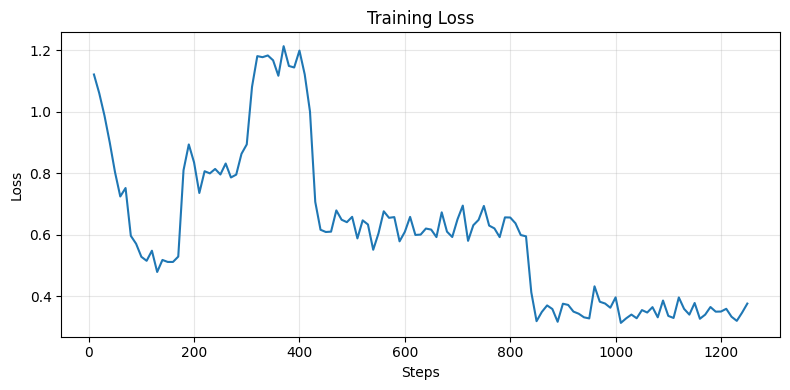

In [ ]:
log_history = trainer.state.log_history
steps = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"] for e in log_history if "loss" in e]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, linewidth=1.5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save Training Model

In [ ]:
model.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_lora_adapters", safe_serialization=True, max_shard_size="2GB")
tokenizer.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_lora_adapters")

# Post-Training Inference

In [ ]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32768, 4096, padding_idx=770)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
              (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
              (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
              (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
            )
            (mlp): MistralMLP(
              (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
              (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
              (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
              (act_fn): SiLUActivation()
          

In [ ]:
print("Running fine-tuned inference....")
finetuned_preds = generate_answer(
    model, tokenizer,
    eval_system_prompts,
    eval_user_prompts,
    batch_size=64,
)

Running fine-tuned inference....
	500/500 done!


### Baseline VS Fine-Tuned

In [ ]:
print("Baseline vs Fine-Tuned MistralAI_7B_Fine-Tuned")
for i in range(3):
  print(f"\nContext: {eval_sample[i]['user_prompt'][:200]}....")
  print(f"Expected: {eval_sample[i]['system_prompt'][:150]}....")
  print(f"Baseline: {baseline_preds[i][:150]}")
  print(f"Fine-Tuned: {finetuned_preds[i][:150]}")

Baseline vs Fine-Tuned MistralAI_7B_Fine-Tuned

Context: Question about Public Sentiment:
How much of a buffer do I need to survive COVID financially?

Context:
The person is a 23-year-old living in Sydney, renting an apartment, and working as a journalist.....
Expected: As an experienced financial advisor, your role is to provide insightful and accurate responses to financial questions and topics. Leverage your extens....
Baseline: of COVID and want to know how much of a buffer they need to survive. Given the current economic climate and the uncertainty surrounding the impact of 
Fine-Tuned: As an experienced financial advisor, your role is to provide insightful and accurate responses to financial questions and topics. Leverage your extens

Context: Request:
Is the following sentence a interrogative, declarative, imperative, or exclamatory sentence?

Context:
What are you searching for?....
Expected: As a finance expert, your role is to provide insightful answers to questions related 

# Automated Evaluation (ROUGE + Grounding)

In [ ]:
# ROUGE comparison
finetuned_rouge = compute_rouge(finetuned_preds, eval_references)

In [ ]:
print("="*50)
print("ROUGE COMPARISON")
print("="*50)
print(f"{'Metric':<12} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("="*50)

for metric in ["rouge1", "rouge2", "rougeL"]:
  base = baseline_rouge[metric]
  ft = finetuned_rouge[metric]
  print(f"{metric:<12} {base:>10.4f} {ft:>12.4f} {ft - base:+10.4f}")

ROUGE COMPARISON
Metric         Baseline   Fine-tuned     Change
rouge1           0.1973       0.2777    +0.0804
rouge2           0.0824       0.1208    +0.0384
rougeL           0.1327       0.1870    +0.0543


In [ ]:
finetuned_grounding = [
    grounding_score(pred, ex['user_prompt'])
    for pred, ex in zip(finetuned_preds, eval_sample)
]

bg = np.mean(baseline_grounding)
fg = np.mean(finetuned_grounding)

In [ ]:
print("Grounding Score:")
print(f"\tBaseline: {bg:.4f}")
print(f"\tFine-tuned: {fg:.4f}")
print(f"\tChange: {fg - bg:+.4f}")

Grounding Score:
	Baseline: 0.2245
	Fine-tuned: 0.3545
	Change: +0.1299


# DeepEval: Faithfulness + Correctness

## Ollama as Judge

In [ ]:
import os
# Set timeouts to 50 minutes BEFORE importing deepeval to ensure they take effect
# This prevents the "gather TIMEOUT" error during long evaluations
os.environ["DEEPEVAL_PER_TASK_TIMEOUT_SECONDS"] = "3000"
os.environ["DEEPEVAL_TASK_GATHER_BUFFER_SECONDS"] = "600"

from deepeval.metrics import FaithfulnessMetric, GEval, AnswerRelevancyMetric
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.models import OllamaModel
from deepeval import evaluate
from deepeval.evaluate import AsyncConfig, ErrorConfig

In [ ]:
# Ollama Cloud LLM-as-Judge (no OpenAI dependency)
import time
import random
import re
import json
import os
import asyncio
import requests
from typing import Any, Optional, Type
from pydantic import BaseModel
from deepeval.models import DeepEvalBaseLLM


def _extract_json_object(text: str) -> str | None:
    if not text:
        return None
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    return m.group(0) if m else None


def _strip_code_fences(text: str) -> str:
    stripped = text.strip()
    if stripped.startswith("```"):
        lines = stripped.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines).strip()
    return text


class OllamaAsJudge(DeepEvalBaseLLM):
    def __init__(
        self,
        model: str,
        api_key: str | None = None,
        base_url: str = "https://ollama.com",
        temperature: float = 0.0,
        generation_kwargs: Optional[dict] = None,
        force_json: bool = True,
        timeout_s: int = 120,
        max_retries: int = 5,
        max_concurrent: int = 1,
        sleep_between_calls_s: float = 0.2,
    ):
        self.model_name = model
        self.api_key = api_key or os.getenv("OLLAMA_API_KEY")
        self.base_url = base_url.rstrip("/")
        self.temperature = float(temperature)
        self.generation_kwargs = generation_kwargs or {}
        self._timeout_s = timeout_s
        self._max_retries = max_retries
        self._force_json = force_json
        self._sleep_between_calls_s = float(sleep_between_calls_s)

        if not self.api_key:
            raise ValueError("Missing OLLAMA_API_KEY. Set OLLAMA_API_KEY in your environment.")

        self._sem = asyncio.Semaphore(max_concurrent)

    def get_model_name(self) -> str:
        return f"ollama-cloud:{self.model_name}"

    def load_model(self) -> Any:
        return None

    def _request(self, payload: dict) -> dict:
        url = f"{self.base_url}/chat"
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json",
        }
        response = requests.post(url, headers=headers, json=payload, timeout=self._timeout_s)
        response.raise_for_status()
        return response.json()

    def generate(self, prompt: str, schema: Optional[Type[BaseModel]] = None):
        payload = {
            "model": self.model_name,
            "messages": [
                {
                    "role": "system",
                    "content": (
                        "You are a strict evaluation model that judges output of other llm models. "
                        "Return ONLY the required JSON (no markdown, no extra keys, no extra tokens)."
                    ),
                },
                {"role": "user", "content": prompt},
            ],
            "stream": False,
            "options": {
                "temperature": self.temperature,
                **self.generation_kwargs,
            },
        }

        if self._force_json:
            payload["format"] = "json"

        last_err = None
        for attempt in range(self._max_retries + 1):
            try:
                data = self._request(payload)
                if isinstance(data, dict) and data.get("error"):
                    raise RuntimeError(data["error"])

                content = (data.get("message") or {}).get("content")
                if not content:
                    content = data.get("response", "")
                content = _strip_code_fences((content or "")).strip()
                if not content:
                    raise ValueError("Empty judge response")

                if schema is None:
                    result = content
                else:
                    try:
                        result = schema.model_validate_json(content)
                    except Exception:
                        maybe = _extract_json_object(content)
                        if maybe is None:
                            raise
                        result = schema.model_validate(json.loads(maybe))

                if self._sleep_between_calls_s > 0:
                    time.sleep(self._sleep_between_calls_s)
                return result

            except requests.HTTPError as e:
                last_err = e
                status = getattr(e.response, "status_code", None)
                if status not in {429, 500, 502, 503, 504} or attempt == self._max_retries:
                    raise

            except (requests.RequestException, ValueError, RuntimeError) as e:
                last_err = e
                if attempt == self._max_retries:
                    raise

            backoff = min(10.0, 2 ** attempt) + random.uniform(0, 0.5)
            time.sleep(backoff)

        raise last_err

    async def a_generate(self, prompt: str, schema: Optional[Type[BaseModel]] = None) -> str:
        async with self._sem:
            result = await asyncio.to_thread(self.generate, prompt, schema)
            if self._sleep_between_calls_s > 0:
                await asyncio.sleep(self._sleep_between_calls_s)
            return result

In [ ]:
# Optional: os.environ["OLLAMA_API_KEY"] = "your_api_key"
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "https://ollama.com")
OLLAMA_JUDGE_MODEL = os.getenv("OLLAMA_JUDGE_MODEL", "deepseek-v3.1:671b-cloud")

judge_model = OllamaAsJudge(
    model=OLLAMA_JUDGE_MODEL,
    base_url=OLLAMA_BASE_URL,
    temperature=0.0,
    timeout_s=300,  # 5 minutes HTTP timeout for the judge itself
    generation_kwargs={
        "num_predict": 1024,
    },
    sleep_between_calls_s=0.5,
)

print(f"Ollama Cloud judge ready: {OLLAMA_JUDGE_MODEL}")

Ollama Cloud judge ready: deepseek-v3.1:671b-cloud


In [ ]:
if "judge_model" not in globals() or judge_model is None:
    raise ValueError("Run the Ollama judge setup cell first.")

# Use sync mode per metric to avoid asyncio wait_for cancellations in notebook runs.
faithfulness = FaithfulnessMetric(
    model=judge_model,
    threshold=0.5,
    async_mode=False,
)

correctness = GEval(
    name="Financial Correctness (Ollama)",
    criteria=(
        "Determine if the actual output correctly answers the financial question "
        "based on the expected output. The actual output should convey the same "
        "financial facts, figures, and conclusions without incorrect information."
    ),
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    threshold=0.7,
    model=judge_model,
    strict_mode=True,
    async_mode=False,
)

relevancy = AnswerRelevancyMetric(
    model=judge_model,
    threshold=0.7,
    async_mode=False,
)

print("DeepEval metrics configured with Ollama judge (sync mode): FaithfulnessMetric + GEval (+ AnswerRelevancyMetric)")


DeepEval metrics configured with Ollama judge (sync mode): FaithfulnessMetric + GEval (+ AnswerRelevancyMetric)


In [ ]:
# Test Cases
JUDGE_SIZE = 30
judge_indices = random.sample(range(EVAL_SIZE), JUDGE_SIZE)

baseline_cases = []
finetuned_cases = []

for idx in judge_indices:
  ex = eval_sample[idx]

  baseline_cases.append(LLMTestCase(
          input=ex["user_prompt"],
          actual_output=baseline_preds[idx],
          expected_output=ex["answer"],
          retrieval_context=[ex["user_prompt"]],
  ))

  finetuned_cases.append(LLMTestCase(
      input=ex["user_prompt"],
      actual_output=finetuned_preds[idx],
      expected_output=ex["answer"],
      retrieval_context=[ex["user_prompt"]],
  ))

print(f"Create {JUDGE_SIZE} test cases each for baseline and fine-tuned")

Create 30 test cases each for baseline and fine-tuned


In [ ]:
print("Evaluating Baseline with LLM-as-Judge....")
baseline_results = evaluate(
    test_cases=baseline_cases,
    metrics=[faithfulness, correctness],
    async_config=AsyncConfig(run_async=False, max_concurrent=1),
    error_config=ErrorConfig(ignore_errors=True),
)
print("Done!")

Evaluating Baseline with LLM-as-Judge....


✨ You're running DeepEval's latest Faithfulness Metric! (using ollama-cloud:deepseek-v3.1:671b-cloud, 
strict=False, async_mode=False)...

✨ You're running DeepEval's latest Financial Correctness (Ollama) [GEval] Metric! (using 
ollama-cloud:deepseek-v3.1:671b-cloud, strict=True, async_mode=False)...

Output()



Metrics Summary

  - ✅ Faithfulness (score: 1.0, threshold: 0.5, strict: False, evaluation model: ollama-cloud:deepseek-v3.1:671b-cloud, reason: The score is 1.00 because there are no contradictions between the actual output and the retrieval context, indicating perfect alignment., error: None)
  - ❌ Financial Correctness (Ollama) [GEval] (score: 0.0, threshold: 1.0, strict: True, evaluation model: ollama-cloud:deepseek-v3.1:671b-cloud, reason: Actual Output misses expected investments like Bio-bean, Renault-Nissan, and bike-sharing as explicit examples, while adding unexpected options such as battery manufacturers, clean energy companies, and car-sharing services., error: None)

For test case:

  - input: Question about Personal Finance:
What are some alternative sustainable transportation investment options in Europe, given that most rail companies are state-owned?

Context:
The user is looking for investment options in alternative sustainable transportation in Europe, but is havin

⚠ WARNING: No hyperparameters logged.
» ]8;id=885304;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 1695.79s | token cost: None)
» Test Results (30 total tests):
   » Pass Rate: 20.0% | Passed: 6 | Failed: 24

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Done!


In [ ]:
print("Evaluating Fine-Tuned with LLM-as-Judge....")
finetuned_results = evaluate(
    test_cases=finetuned_cases,
    metrics=[faithfulness, correctness],
    async_config=AsyncConfig(run_async=True, max_concurrent=5),
    error_config=ErrorConfig(ignore_errors=True),
)
print("Done!")

Evaluating Fine-Tuned with LLM-as-Judge....


✨ You're running DeepEval's latest Faithfulness Metric! (using ollama-cloud:deepseek-v3.1:671b-cloud, 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Financial Correctness (Ollama) [GEval] Metric! (using 
ollama-cloud:deepseek-v3.1:671b-cloud, strict=True, async_mode=True)...

Output()

INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
INFO:deepeval.metrics.indicator:caught asyncio.CancelledError
INFO:deepeval.metrics.indicator:caught



Metrics Summary

  - ✅ Faithfulness (score: 1.0, threshold: 0.5, strict: False, evaluation model: ollama-cloud:deepseek-v3.1:671b-cloud, reason: The score is 1.00 because there are no contradictions, indicating perfect alignment between the actual output and the retrieval context—great job!, error: None)
  - ❌ Financial Correctness (Ollama) [GEval] (score: 0.0, threshold: 1.0, strict: True, evaluation model: ollama-cloud:deepseek-v3.1:671b-cloud, reason: Actual Output omits Tesla, Renault-Nissan, Bio-bean, EV charging networks, and bike-sharing services mentioned in Expected Output, and adds incorrect elements like ETFs and ride-sharing platforms., error: None)

For test case:

  - input: Question about Personal Finance:
What are some alternative sustainable transportation investment options in Europe, given that most rail companies are state-owned?

Context:
The user is looking for investment options in alternative sustainable transportation in Europe, but is having difficulty findi

⚠ WARNING: No hyperparameters logged.
» ]8;id=513021;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 208.7s | token cost: None)
» Test Results (15 total tests):
   » Pass Rate: 6.67% | Passed: 1 | Failed: 14

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Done!


In [ ]:
# extract and compare scores
def extract_scores(test_cases, metric_name):
  scores = []
  for test_case in test_cases:
    for metric_result in test_case.metric_data:
      if metric_result.name == metric_name:
        scores.append(metric_result.score)

  return scores

In [ ]:
# faithfullness scores
base_faith = extract_scores(baseline_cases, "Faithfulness")
ft_faith = extract_scores(finetuned_cases, "Faithfulness")

AttributeError: 'LLMTestCase' object has no attribute 'metric_data'

In [ ]:
# correctness scores
base_correct = extract_scores(baseline_cases, "Financial Correctness")
ft_correct = extract_scores(finetuned_cases, "Financial Correctness")

In [ ]:
print("="*50)
print("LLM-as-Judge Comparison")
print("="*50)
print(f"{'Metric':<25} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("="*50)

if base_faith and ft_faith:
  bf, ff = np.mean(base_faith), np.mean(ft_faith)
  print(f"{'Financial Correctness':<25} {bf:>10.4f} {ff:>12.4f} {ff - bf:>+10.4f}")

if base_faith and ft_faith:
  print("\nFaithfulness pass rate (>0.end=)")
  print(f"\tBaseline: {100*sum(s >= 0.7 for s in base_faith)/len(base_faith):.1f}%")
  print(f"\tFine-tuned: {100*sum(s >= 0.7 for s in ft_faith)/len(ft_faith):.1f}%")

# Error Analysis
  - Context-grounded QA, the most important error is low hallucination rate/unfaithful answers.

In [ ]:
sorted_by_grounding = np.argsort(finetuned_grounding)

In [ ]:
print("====== Most Hallucinated answers (lowest grounded)")
for rank, idx in enumerate(sorted_by_grounding[:5]):
  print(f"\n[Grounding: {finetuned_grounding[idx]:.3f}]")
  print(f"\tContext (start): {eval_sample[idx]['user_prompt'][:120]}....")
  print(f"\tExpected: {eval_references[idx][:120]}")
  print(f"\tAnswered: {finetuned_preds[idx][:120]}")

In [ ]:
print("====== Most Grounded (highest grounding) ======")
for rank, idx in enumerate(sorted_by_grounding[-5:]):
  print(f"\n[Grounding: {finetuned_grounding[idx]:.3f}]")
  print(f"\tContext (start): {eval_sample[idx]['user_prompt'][:120]}....")
  print(f"\tExpected: {eval_references[idx][:120]}")
  print(f"\tAnswered: {finetuned_preds[idx][:120]}")

In [ ]:
# Checking if model over generate or undergenerates
ref_lengths = [len(r.split()) for r in eval_references]
base_lengths = [len(r.split()) for r in baseline_preds]
ft_lengths = [len(r.split()) for r in finetuned_preds]

In [ ]:
print("Answer Length (words):")
print(f"\tReference: mean={np.mean(ref_lengths):.0f}, median={np.median(ref_lengths):.0f}")
print(f"\tBaseline: mean={np.mean(base_lengths):.0f}, median={np.median(base_lengths):.0f}")
print(f"\tFine-tuned: mean={np.mean(ft_lengths):.0f}, median={np.median(ft_lengths):.0f}")

print("Length ratio (prediction / reference):")
base_ratios = [b/r if r>0 else 0 for b, r in zip(base_lengths, ref_lengths)]
ft_ratios = [f/r if r>0 else 0 for f, r in zip(ft_lengths, ref_lengths)]
print(f"\tBaseline: {np.mean(base_ratios):.2f} [incorrect]!")
print(f"\tFine-tuned: {np.mean(ft_ratios):.2f} [incorrect]!")
print(f"\t(1.0) are perfect length match.")

# Evaluation Summary

In [ ]:
print("\n" + "="*50)
print("Evaluation Summary")
print("="*50)

print(f"\n{'Metric':<25} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("="*50)

# ROUGE
for metric in ["rouge1", "rouge2", "rougeL"]:
  b, f = baseline_rouge[metric], finetuned_rouge[metric]
  print(f"{metric:<25} {b:>10.4f} {f:>12.4f} {f - b:>+10.4f}")

# grounding
print(f"{'Grounding Score':<25} {np.mean(baseline_grounding):>10.4f} {np.mean(finetuned_grounding):>12.4f} {np.mean(finetuned_grounding)-np.mean(baseline_grounding):>+10.4f}")

# DeepEval
if base_faith and ft_faith:
  bf, ff = np.mean(base_faith), np.mean(ft_faith)
  print(f"{'Faithfulness':<25} {bf:>10.4f} {ff:>12.4f} {ff - bf:>+10.4f}")

if base_correct and ft_correct:
  bc, fc = np.mean(base_correct), np.mean(ft_correct)
  print(f"{'Financial Correctness':<25} {bc:>10.4f} {fc:>12.4f} {fc - bc:>+10.4f}")

print("\n" + "="*50)

# Save Model to SafeTensors